In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import EarthMotion_tmp
import parametrics
JD0 = 0
from emcee.autocorr import integrated_time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner


import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)
vEarth = EarthMotion_tmp.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
import EarthMotion_tmp
print(EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg))
print(EarthMotion.calc_vEarth(tref+2450000,RA_deg,Dec_deg))

print(EarthMotion_tmp.calc_vEarth(tref,RA_deg,Dec_deg))
print(EarthMotion_tmp.calc_vEarth(tref+2450000,RA_deg,Dec_deg))

(np.float64(-0.42944823204271027), np.float64(-3.854637062559252))
(np.float64(-0.42944823204271027), np.float64(-3.854637062559252))
(np.float64(0.47549029969226014), np.float64(-0.672425393185752))
(np.float64(-0.42944823204271027), np.float64(-3.854637062559252))


In [3]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [4]:
@jit
def lightcurve_to_physical(theta,thS,DS,vEarth, G = 2.959122082855911e-4, KAPPA = 8.1429):
    # G [AU^3 / (Msun * day^2)] , KAPPA [mas / Msun]
    t0 = theta[0]
    tE     = theta[1]
    u0 = theta[2]
    rho    = theta[3]
    q = theta[4]
    s      = theta[5]
    alpha = theta[6]
    piEN   = theta[7]
    piEE   = theta[8]
    vEarth_N, vEarthE = vEarth
    
    G = 2.959122082855911e-4 # [AU^3 / (Msun * day^2)]
    KAPPA = 8.1429 # [mas / Msun]

    piE = jnp.sqrt(piEN**2 + piEE**2)

    thE = thS / rho #mas
    ML = thE / KAPPA / piE #Msun
    murel_geo = thE / tE * 365.25 # mas / year
    murel_N_geo = murel_geo * piEN / piE # mas / year
    murel_E_geo = murel_geo * piEE / piE # mas / year

    pi_rel = thE * piE
    pi_S = 1 / DS
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L #kpc
    
    murel_N_hel = murel_N_geo + thE * piE * vEarth[0]
    murel_E_hel = murel_E_geo + thE * piE * vEarth[1]

    return  jnp.array([ML, DL, DS, murel_N_hel, murel_E_hel])


In [5]:
def calc_tau(arr):
    taus = []
    for pi in range(arr.shape[2]):
        tau_walkers = []
        for w in range(arr.shape[1]):
            chain = arr[:, w, pi]
            tau = emcee.autocorr.integrated_time(chain[:, None], quiet=True)
            tau_walkers.append(tau.item())
        mean_tau = np.mean(tau_walkers)
        taus.append(mean_tau)
        print(f"param[{pi}] mean τ_int over {arr.shape[1]} walkers = {mean_tau:.2f}")

    return max(taus)
    

In [6]:
def weighted_percentile(data, weights, percentiles=[16, 50, 84]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]
    return np.interp(np.array(percentiles)/100, cumsum, data_sorted)

mu_rel_N  = 3.000000  # mas/yr
mu_rel_E  = 3.000000  # mas/yr
M_L      = 0.523487      # M_sun
D_L       = 3.663743      # kpc
D_S       =  8.142611        # kpc
R_orbit   = 2.999999 #  # AU
e   =  0.500000
cos_i    = 0.620905
omega    = -1.177002
Omega    =  (0.572726- np.pi)% (2*np.pi)
nu    = -1.964761

t0_true = 10085 
u0_true = 0.01 
q_true = 0.005
alpha_true =  3.65*np.pi/4
tE_true = 68.5053
rho_true = 8.96025e-05
s_true =  0.950001
piEN_true = 0.128858
piEE_true = 0.136441
gamma1_true = -0.00137559
gamma2_true = 0.00149516
gamma3_true = -0.00188781
r_s_true = 0.000133878
a_s_true = 1.07743
thS_true = 0.0001800539

truths_lc_04 = [t0_true, tE_true,u0_true, rho_true, q_true, s_true, alpha_true,
                piEN_true, piEE_true, gamma1_true, gamma2_true, gamma3_true,
                r_s_true, a_s_true]

truths_kep_04 = [M_L, D_L, D_S, mu_rel_N, mu_rel_E, R_orbit,
                 e, cos_i,  Omega,omega, nu]

In [7]:

mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [8]:
label_inds_kep = {"t0": 0, "tE": 1, "u0": 2, "rho": 3, "q": 4, "s": 5, "alpha": 6,
                  "piEN": 7, "piEE": 8, "gamma1": 9, "gamma2": 10, "gamma3": 11,
                  "rs": 12, "as": 13}

label_inds_kep_phys = {"ML": 3, "DL": 4, "DS": 5, "muN": 6, "muE": 7, "a": 8,
                       "e": 9, "cos_i": 10, "Omega": 11, "omega": 12, "nu": 13}

In [9]:
def read_chain(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin) 
    lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin) 
    return chain, blob,lnprob

names = "wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L     K_L iS iL fREM".split()

def load_genulens(path):
    genulens_out = np.genfromtxt(path,names=names)
    wtj = genulens_out["wtj"] / np.sum(genulens_out["wtj"])
    ML_genu = genulens_out["M_L"]
    DL_genu = genulens_out["D_L"] * 1e-3
    DS_genu = genulens_out["D_S"] * 1e-3
    muN_genu = genulens_out["mu_rel"] * genulens_out["pi_EN"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[0]
    muE_genu = genulens_out["mu_rel"] * genulens_out["pi_EE"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[1]

    return np.array(wtj), np.array([ML_genu,DL_genu,DS_genu,muN_genu,muE_genu ]).T

wt, genuout = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/Ds_prior.dat")

In [10]:
chain_para, blob_para = np.load("../test_result/array/kep_wo_chain_02.npy")[:,:9], np.load("../test_result/array/kep_wo_brob_02.npy")

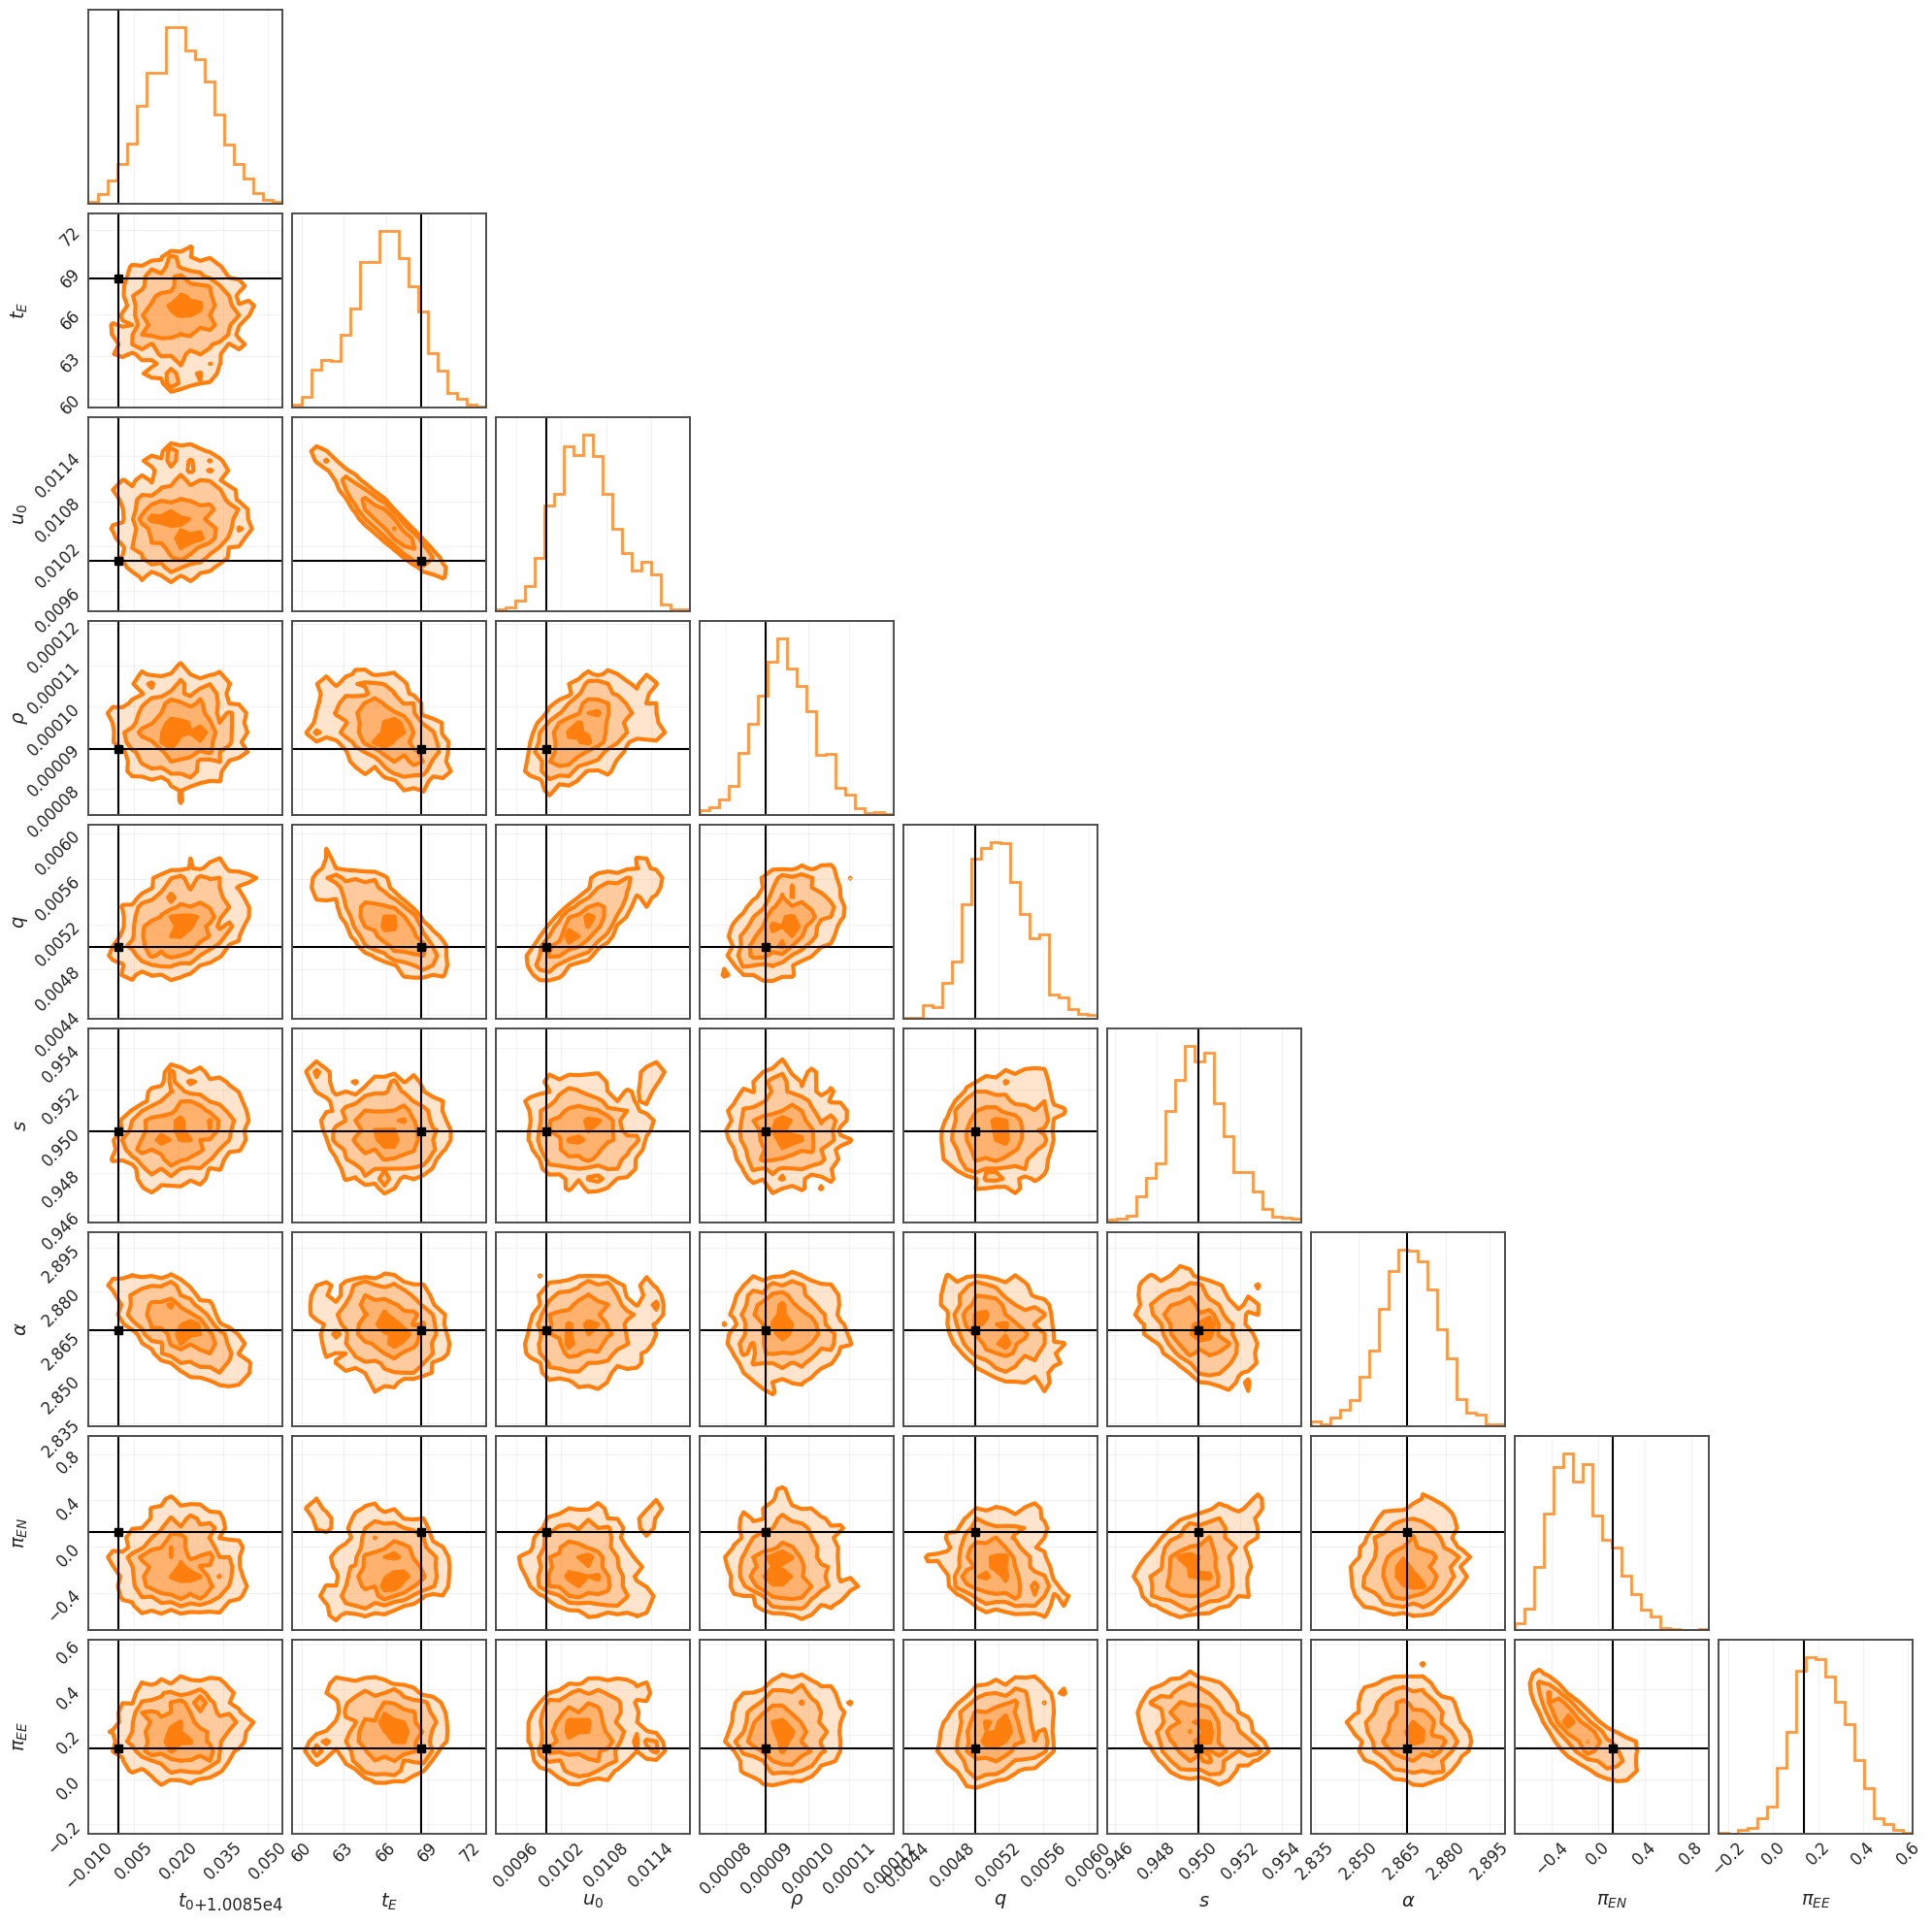

In [11]:
_labels = [
    r"$t_{0}$",
    r"$t_E$",
    r"$u_0$",
    r"$\rho$",
    r"$q$",r"$s$",r"$\alpha$","$\pi_{EN}$","$\pi_{EE}$"
]

corner.corner(chain_para,color="C1",labels=_labels,truths=truths_lc_04[:9],truth_color="k",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 2, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5,)

handles = [
    Line2D([], [], color="C0", lw=5, label="static"),
    Line2D([], [], color="C1", lw=5, label="parallax"),
]

plt.show()

In [12]:
Ds = genuout[:chain_para.shape[0], 2]  # shape: (N,)

_vmap = jax.vmap(
    lambda theta, thS, D_S : lightcurve_to_physical(theta, thS, D_S, vEarth),
    in_axes=(0, 0, 0)
)

result = np.array(_vmap(chain_para, blob_para, Ds))

In [13]:
bounds = {
    "tE":    (60, 80),
#     "rho":   (0.00015, 0.00018),
    "rho":   (5e-4, 15e-4),
#     "piEN":  (-0.5, 0.4),
#     "piEE":  (-0.2, 0.6)
#     "tE":    (0.1, 1000),
#     "rho":   (0, 1),
    "piEN":  (-3, 3),
    "piEE":  (-3, 3),
}

rng = np.random.default_rng(seed=42)
samples = np.stack([
    rng.uniform(low, high,chain_para.shape[0] )
    for (low, high) in bounds.values()], axis=-1)

uni_chain = chain_para.copy()
uni_chain[:,1] = samples[:,0]
uni_chain[:,3] = samples[:,1]
uni_chain[:,7] = samples[:,2]
uni_chain[:,8] = samples[:,3]

_vmap_fix = jax.vmap(
    lambda theta, D_S: lightcurve_to_physical(theta, thS_true, D_S, vEarth),
    in_axes=(0, 0)
)

result_prior = np.array(_vmap_fix(uni_chain, Ds))

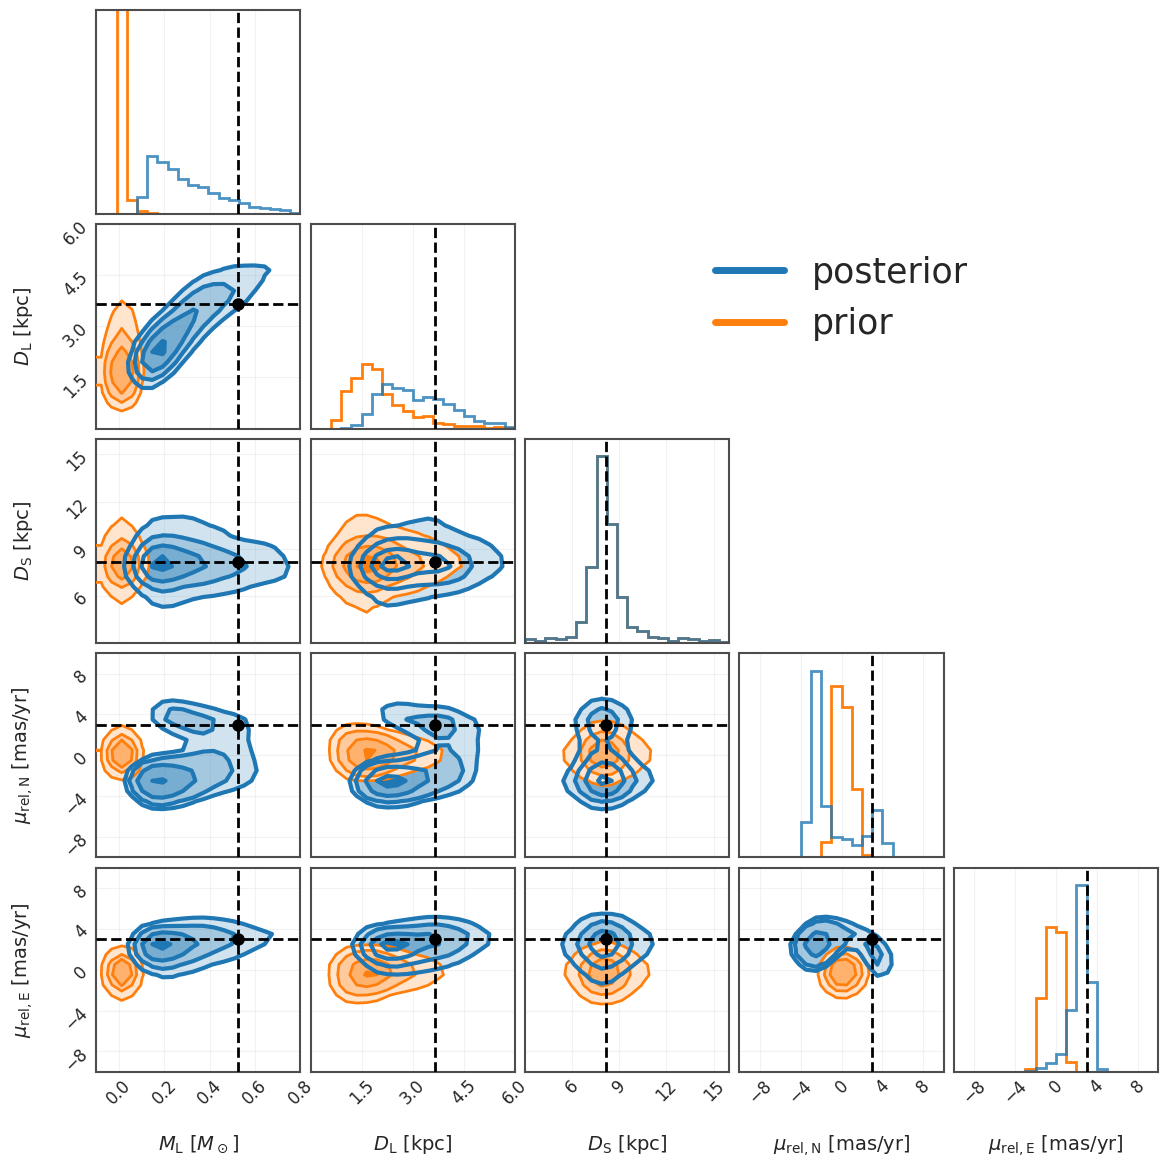

In [14]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0.1, 0.8),   # M_L
    (0, 6),       # D_L
    (3, 16),       # D_S
    (-10, 10),       # mu_rel_N
    (-10, 10),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------
fig = corner.corner(
    result,               # shape: (Nsamples, 5) を想定
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

corner.corner(
    result_prior,        # shape: (Nsamples_prior, 5) を想定
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

ndim = result.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------
truths = truths_kep_04[:5]

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 13),    # M_L
    (0, 2),  # D_L
    (0, 0.6),  # D_S
    (0, 0.5),  # mu_rel_N
    (0, 0.55),    # mu_rel_E
]

for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]

axes[1, -2].legend(
    handles=handles,
    fontsize=25,
    loc="upper center",
    frameon=False,
)

# レイアウト微調整
fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


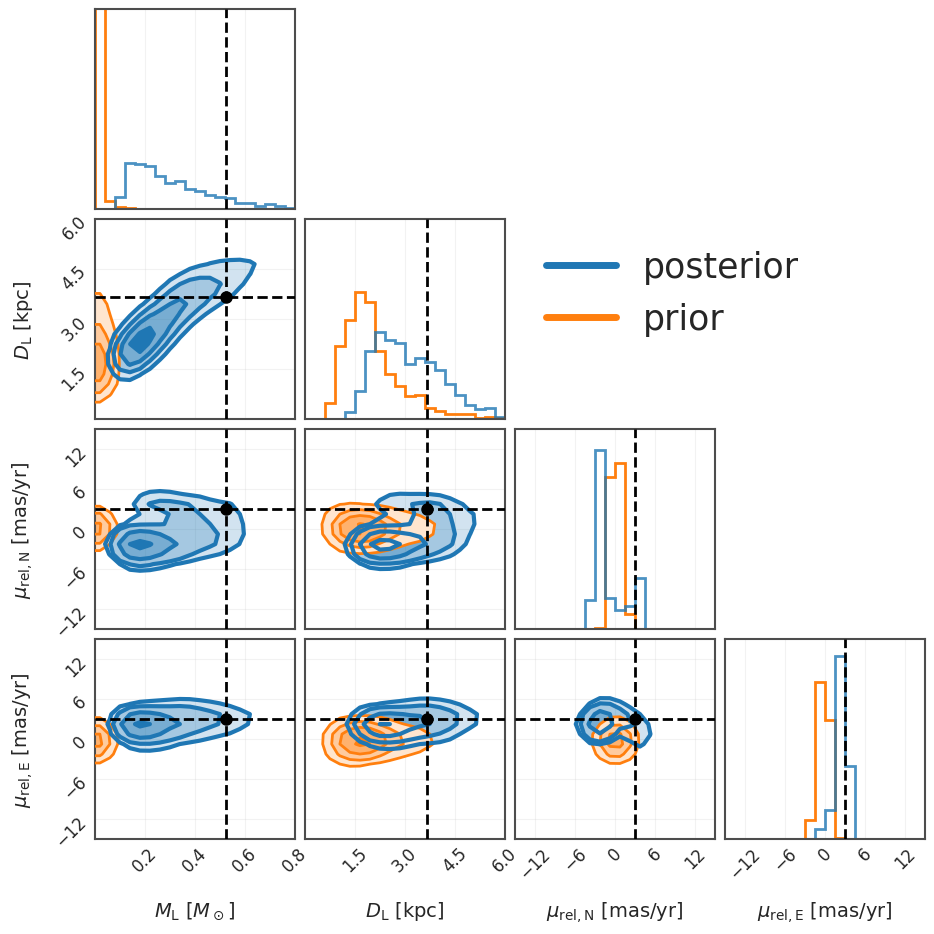

In [15]:
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-0., 0.8),
    (-0, 6),
    (-15, 15),
    (-15, 15),
]

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 15),
    (0, 1),
    (0, 0.4),
    (0, 0.45),
]

for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]

axes[1, -2].legend(
    handles=handles,
    fontsize=25,
    loc="upper left",
    frameon=False,
)

# fig.subplots_adjust(
#     left=0.08,
#     right=0.98,
#     bottom=0.08,
#     top=0.98,
#     wspace=0.05,
#     hspace=0.05,
# )

plt.savefig("/moao38_7/nunota/gapmoe/test_figures/simu_02_corner_direct.pdf")
plt.show()


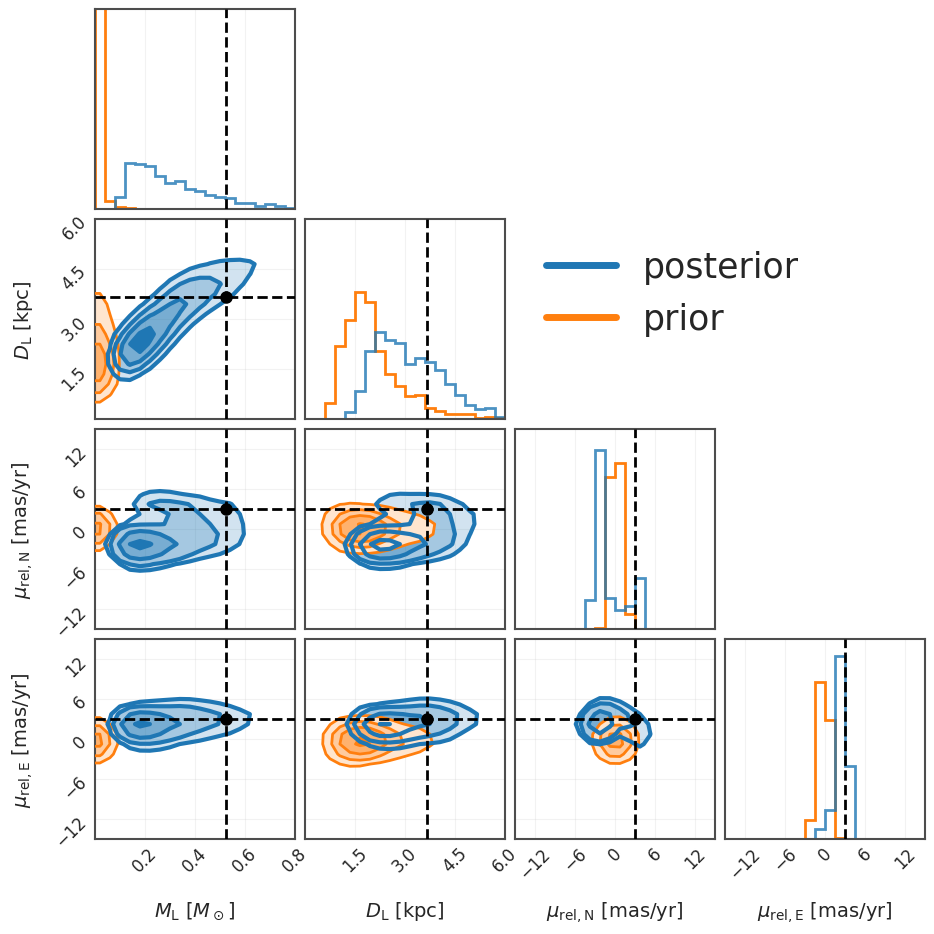

In [16]:
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-0., 0.8),
    (-0, 6),
    (-15, 15),
    (-15, 15),
]

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 15),
    (0, 1),
    (0, 0.4),
    (0, 0.45),
]

for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]

axes[1, -2].legend(
    handles=handles,
    fontsize=25,
    loc="upper left",
    frameon=False,
)

# fig.subplots_adjust(
#     left=0.08,
#     right=0.98,
#     bottom=0.08,
#     top=0.98,
#     wspace=0.05,
#     hspace=0.05,
# )

plt.show()


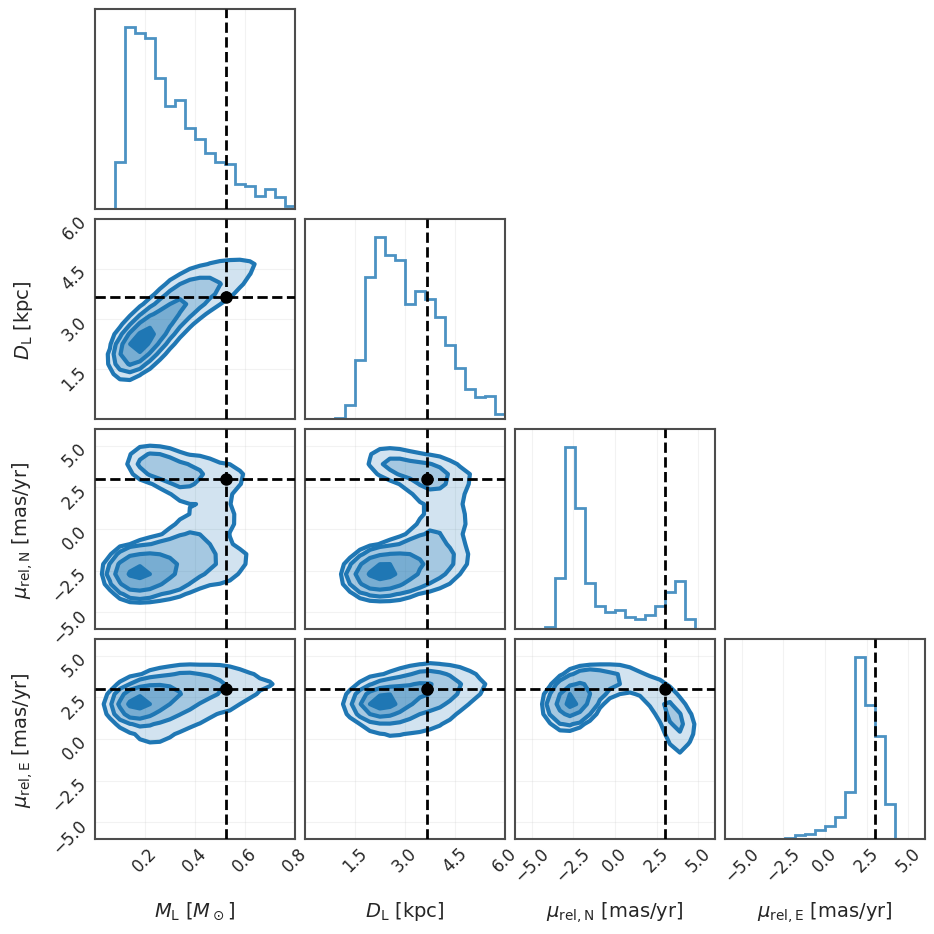

In [17]:
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-0., 0.8),
    (-0, 6),
    (-6, 6),
    (-6, 6),
]

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)


handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]


# fig.subplots_adjust(
#     left=0.08,
#     right=0.98,
#     bottom=0.08,
#     top=0.98,
#     wspace=0.05,
#     hspace=0.05,
# )

plt.show()


In [18]:
gap_result = np.load("../test_result/array/kep_gap_phys_02.npy")

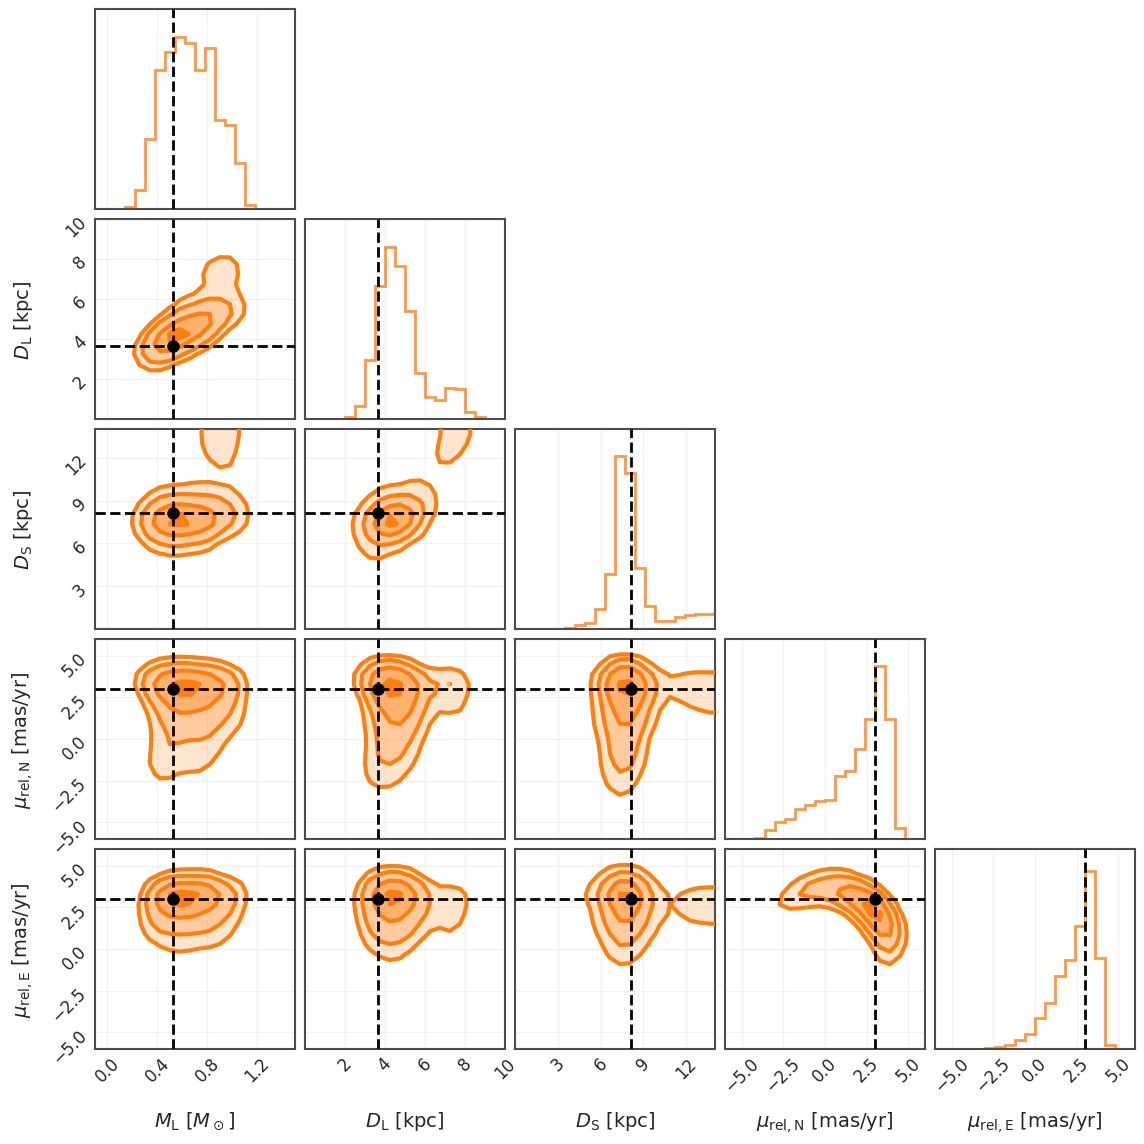

In [19]:
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-0.1, 1.5),
    (-0, 10),
    (-0, 14),
    (-6, 6),
    (-6, 6),
]

idx = [0, 1, 2, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    gap_result[:,[3, 4, 5, 6, 7]],
    labels=labels_phys,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
(0, 2.),
(0, 0.5),
(0, 0.5),
(0, 0.4),
(0, 0.5),
]
for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]


# fig.subplots_adjust(
#     left=0.08,
#     right=0.98,
#     bottom=0.08,
#     top=0.98,
#     wspace=0.05,
#     hspace=0.05,
# )

plt.show()


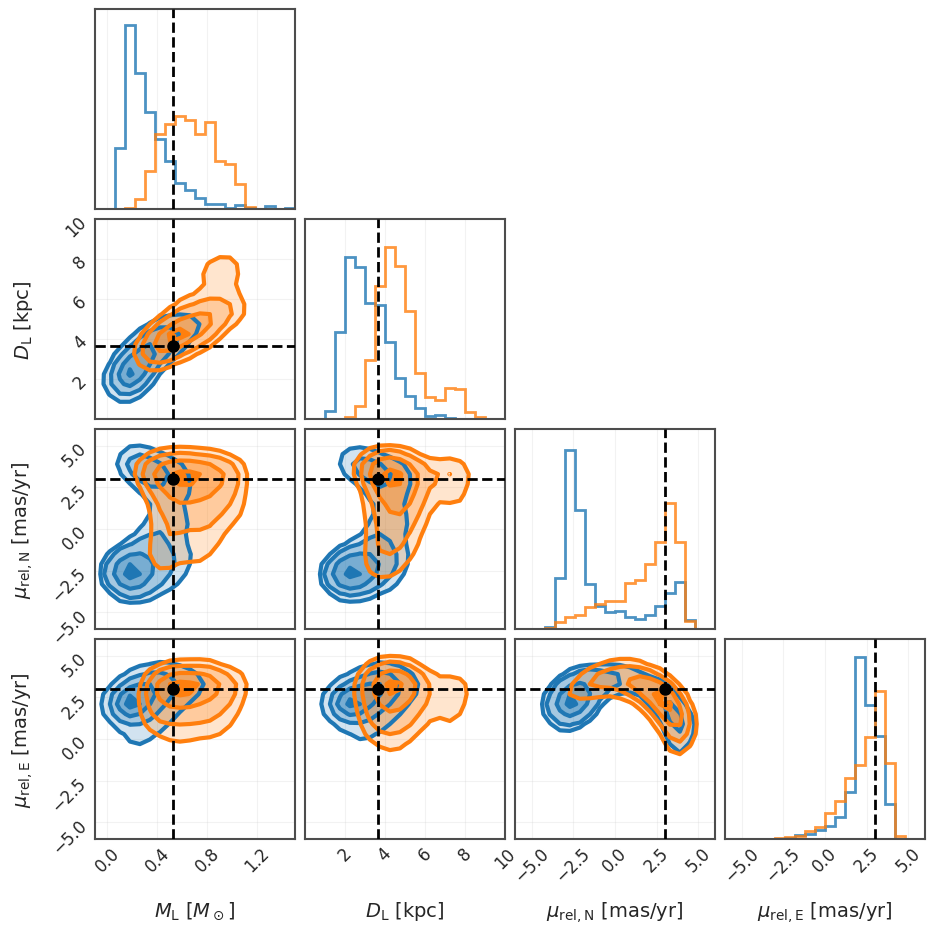

In [29]:
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-0.1, 1.5),
    (-0, 10),
    (-6, 6),
    (-6, 6),
]

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    gap_result[:,[3, 4, 6, 7]],
    labels=labels_phys,
    range=ranges,
    fig = fig,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
(0, 3.7),
(0, 0.5),
(0, 0.55),
(0, 0.6),
]
for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]


# fig.subplots_adjust(
#     left=0.08,
#     right=0.98,
#     bottom=0.08,
#     top=0.98,
#     wspace=0.05,
#     hspace=0.05,
# )

plt.show()


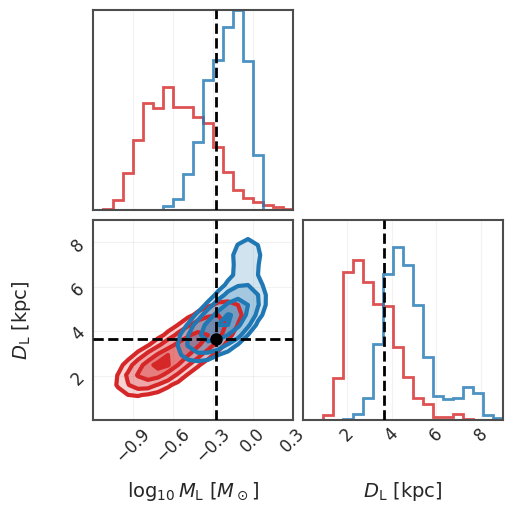

In [36]:
# ======================
# ML, DL のみ（ML は log10）
# ======================
labels_phys = [
    r"$\log_{10} M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
]

# log10(ML) 用のレンジ（必要に応じて調整）
ranges = [
    (-1.2, 0.3),   # log10(ML)
    (0.0, 9),   # DL
]

# result 側の列（元コードの idx=[0,1,3,4] から ML=0, DL=1 を採用）
idx = [0, 1]

result_plot = result[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

# gap_result 側は元コードで [3,4,6,7] を使っていたので ML=3, DL=4 を採用
gap_plot = gap_result[:, [3, 4]].copy()

# ---- ML を log10 変換（0 以下対策に clip）
result_plot[:, 0] = np.log10(np.clip(result_plot[:, 0], 1e-12, None))
gap_plot[:, 0]    = np.log10(np.clip(gap_plot[:, 0],    1e-12, None))
truths[0]         = np.log10(np.clip(truths[0],         1e-12, None))

# ======================
# corner: result
# ======================
fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C3",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

# ======================
# corner: gap_result を重ね描き
# ======================
corner.corner(
    gap_plot,
    labels=labels_phys,
    range=ranges,
    fig=fig,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

# ======================
# 軸装飾 + truths
# ======================
ndim = 2
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in",
                       top=True, right=True, labelsize=12)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# オフ対角（DL vs logML）
axes[1, 0].axhline(truths[1], color="k", ls="--", lw=2, zorder=9)
axes[1, 0].axvline(truths[0], color="k", ls="--", lw=2, zorder=9)
axes[1, 0].plot(truths[0], truths[1], "o", color="k", ms=8, zorder=10)

# 対角
axes[0, 0].axvline(truths[0], color="k", ls="--", lw=2, zorder=9)
axes[1, 1].axvline(truths[1], color="k", ls="--", lw=2, zorder=9)

# 対角ヒストの y 範囲（必要なら調整）
ylims = [
    (0, 2.),  # log10(ML)
    (0, 0.5),  # DL
]
for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

plt.show()

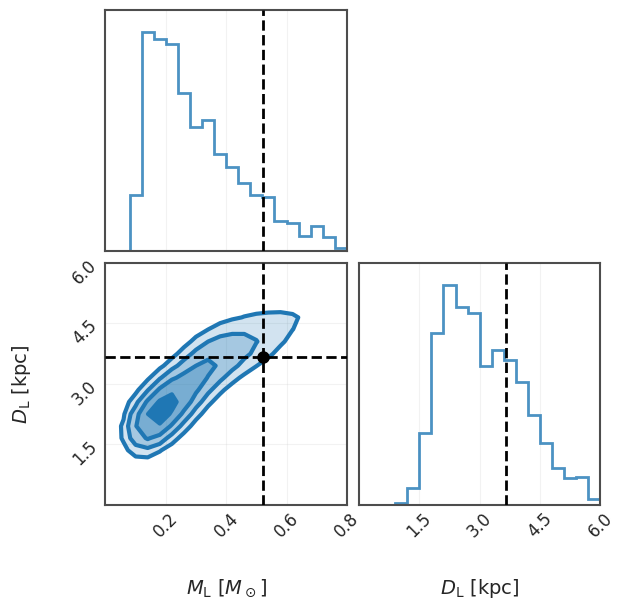

In [21]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0., 0.8),   # M_L
    (0, 6),       # D_L
    (3, 16),       # D_S
    (-6,6),       # mu_rel_N
    (-6, 6),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------
fig = corner.corner(
    result[:,:2],               # shape: (Nsamples, 5) を想定
    labels=labels_phys[:2],
    range=ranges[:2],
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)


ndim = 2
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------
truths = truths_kep_04[:2]

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

# レイアウト微調整
fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


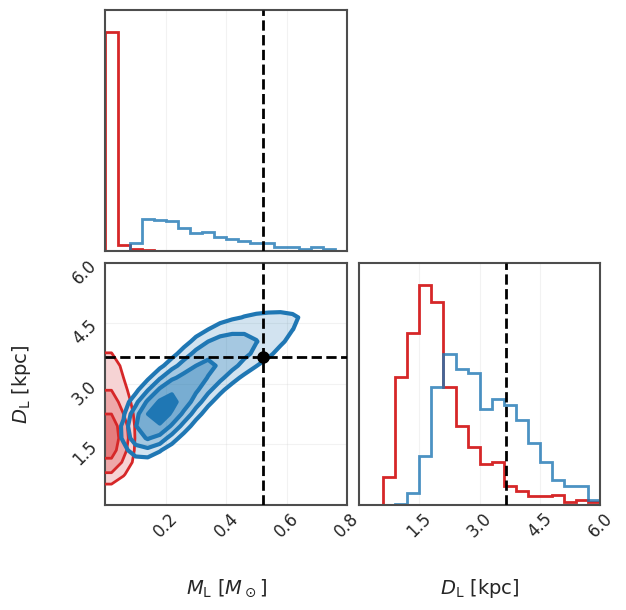

In [22]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0., 0.8),   # M_L
    (0, 6),       # D_L
    (3, 16),       # D_S
    (-6,6),       # mu_rel_N
    (-6, 6),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------
fig = corner.corner(
    result[:,:2],               # shape: (Nsamples, 5) を想定
    labels=labels_phys[:2],
    range=ranges[:2],
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

corner.corner(
    result_prior_plot[:,:2],
    fig=fig,
    range=ranges[:2],
    color="C3",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)


ndim = 2
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------
truths = truths_kep_04[:2]

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

# レイアウト微調整
fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


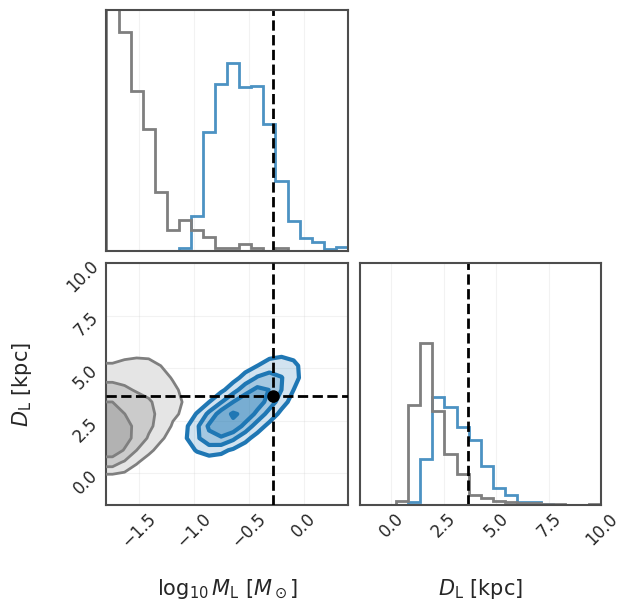

In [23]:
# ------------------------
# 対数化（M_Lのみ）
# ------------------------
result_plot = result[:, :2].copy()
prior_plot  = result_prior_plot[:, :2].copy()
truths = truths_kep_04[:2].copy()

# M_L → log10
result_plot[:, 0] = np.log10(result_plot[:, 0])
prior_plot[:, 0]  = np.log10(prior_plot[:, 0])
truths[0]         = np.log10(truths[0])

# ラベル（M_Lだけlog）
labels_plot = [
    r"$\log_{10} M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
]

# 表示範囲（log空間）
ranges_plot = [
    (-1.8, 0.4),   # log10(M_L)
    (-1.5, 10),       # D_L（線形）
]

# ------------------------
# corner plot
# ------------------------
fig = corner.corner(
    result_plot,
    labels=labels_plot,
    range=ranges_plot,
    color="C0",
    hist_kwargs=dict(density=True, linewidth=2, alpha=0.8, histtype="step"),
    contour_kwargs=dict(zorder=5, linewidths=3),
    fill_contours=True,
    no_fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    prior_plot,
    fig=fig,
    range=ranges_plot,
    color="C7",
    hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
    contour_kwargs=dict(zorder=3, linewidths=2),
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

# ------------------------
# 軸整形
# ------------------------
ndim = 2
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=12)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン
# ------------------------
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    axes[i, i].axvline(truths[i], color="k", linestyle="--", lw=2)
    
ylims = [
    (0, 2),   # log10(M_L)
    (0, .9),   # D_L
]

for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08, right=0.98, bottom=0.08, top=0.98,
    wspace=0.05, hspace=0.05
)

plt.show()


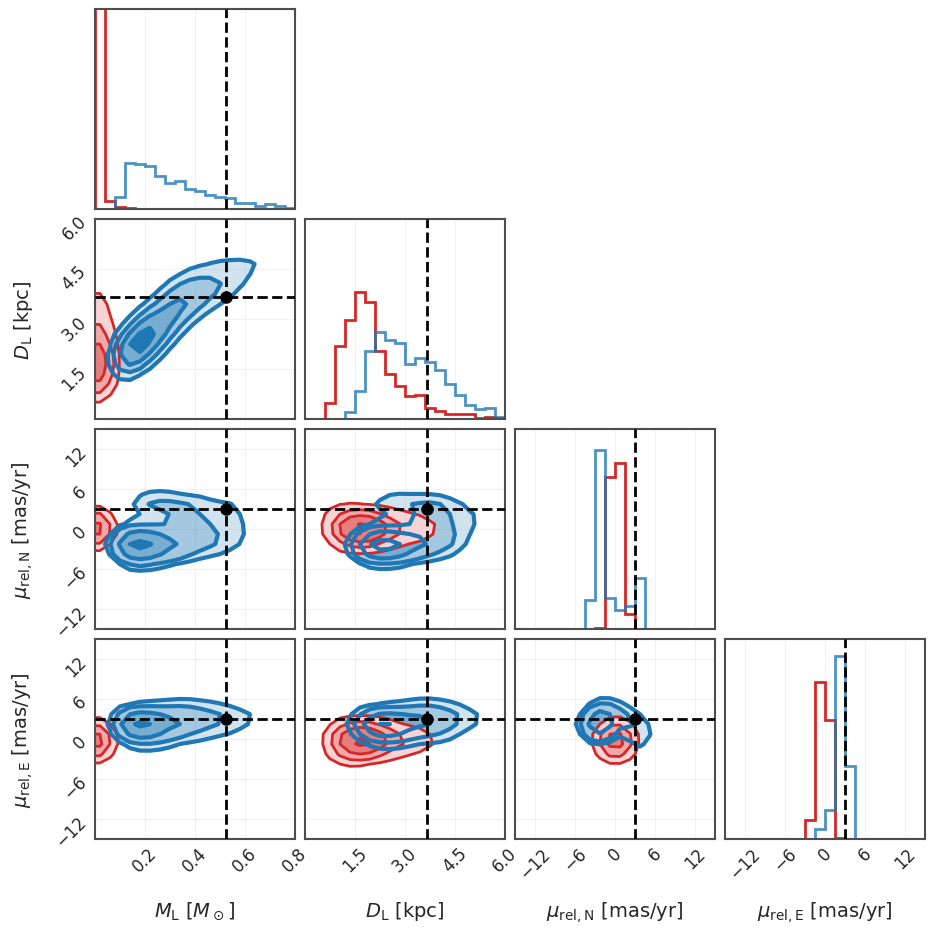

In [24]:
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-0., 0.8),
    (-0, 6),
    (-15, 15),
    (-15, 15),
]

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges,
    color="C3",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 15),
    (0, 1),
    (0, 0.4),
    (0, 0.45),
]

for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])


# fig.subplots_adjust(
#     left=0.08,
#     right=0.98,
#     bottom=0.08,
#     top=0.98,
#     wspace=0.05,
#     hspace=0.05,
# )

plt.show()


In [25]:
chain_para, blob_para = np.load("../test_result/array/kep_wo_chain_02.npy"), np.load("../test_result/array/kep_wo_brob_02.npy")

In [26]:
def weighted_percentile(data, weights, percentiles=[5, 95]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]

    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]

    return np.interp(np.array(percentiles) / 100.0, cumsum, data_sorted)

tref = 10085

params_lc = [
    dict(
        name=r"$t_0 - 10085$",
        unit=r"day",
        key="t0",
        idx=label_inds_kep["t0"],      # gap 側のインデックス
        idx_wo=label_inds_kep["t0"],   # static_wo 側のインデックス
        truth=t0_true - tref,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap=r"$\mathcal{U}(10000,11000)$",
        prior_wo=r"$\mathcal{U}(10000,11000)$",
        transform=lambda x: x - tref,
    ),
    dict(
        name=r"$t_{\rm E}$",
        unit=r"day",
        key="tE",
        idx=label_inds_kep["tE"],
        idx_wo=label_inds_kep["tE"],
        truth=tE_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(60,80)$",
        prior_wo=r"$\mathcal{U}(60,80)$",
    ),
    dict(
        name=r"$u_0$",
        unit=r"$10^{-2}$",
        key="u0",
        idx=label_inds_kep["u0"],
        idx_wo=label_inds_kep["u0"],
        truth=u0_true,
        scale=1e2,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-5,5)$",
        prior_wo=r"$\mathcal{U}(-5,5)$",
    ),
    dict(
        name=r"$\rho$",
        unit=r"$10^{-3}$",
        key="rho",
        idx=label_inds_kep["rho"],
        idx_wo=label_inds_kep["rho"],
        truth=rho_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(0,2 \times 10^{-4})$",
        prior_wo=r"$\mathcal{U}(0,1)$",
    ),
    dict(
        name=r"$q$",
        unit=r"$10^{-2}$",
        key="q",
        idx=label_inds_kep["q"],
        idx_wo=label_inds_kep["q"],
        truth=q_true,
        scale=1e2,
        fmt="{:.2f}",
        prior_gap=r"\text{log}~$\mathcal{U}(10^{-5},1)$",
        prior_wo=r"\text{log}~$\mathcal{U}(10^{-5},1)$",
    ),
    dict(
        name=r"$s$",
        unit=r"---",
        key="s",
        idx=label_inds_kep["s"],
        idx_wo=label_inds_kep["s"],
        truth=s_true,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap=r"$\mathcal{U}(0,5)$",
        prior_wo=r"$\mathcal{U}(0,5)$",
    ),
    dict(
        name=r"$\alpha$",
        unit=r"rad",
        key="alpha",
        idx=label_inds_kep["alpha"],
        idx_wo=label_inds_kep["alpha"],
        truth=alpha_true,
        scale=1.0,
        fmt="{:.3f}",
        prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
        prior_wo=r"$\mathcal{U}(-\pi,\pi)$",
    ),
    dict(
        name=r"$\pi_{\rm E,N}$",
        unit=r"$10^{-1}$",
        key="piEN",
        idx=label_inds_kep["piEN"],
        idx_wo=None,  # static_wo には入っていないので None → No-gap 列は --- にする
        truth=piEN_true,
        scale=10.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-1,1)$",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\pi_{\rm E,E}$",
        unit=r"$10^{-1}$",
        key="piEE",
        idx=label_inds_kep["piEE"],
        idx_wo=None,  # ここも static_wo には無い
        truth=piEE_true,
        scale=10.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-1,1)$",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\gamma_1$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma1",
        idx=label_inds_kep["gamma1"],
        idx_wo=None,
        truth=gamma1_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-3,3)$",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\gamma_2$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma2",
        idx=label_inds_kep["gamma2"],
        idx_wo=None,
        truth=gamma2_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-3,3)$",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\gamma_3$",
        unit=r"$10^{-3}~{\rm day}^{-1}$",
        key="gamma3",
        idx=label_inds_kep["gamma3"],
        idx_wo=None,
        truth=gamma3_true,
        scale=1e3,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-3,3)$",
        prior_wo=r"---",
    ),
    dict(
        name=r"$r_s$",
        unit=r"---",
        key="rs",
        idx=label_inds_kep["rs"],
        idx_wo=None,
        truth=r_s_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"$\mathcal{U}(-10,10)$",
        prior_wo=r"---",
    ),
    dict(
        name=r"$a_s$",
        unit=r"---",
        key="as",
        idx=label_inds_kep["as"],
        idx_wo=None,
        truth=a_s_true,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap="$\mathcal{U}(0,10)$",
        prior_wo=r"---",
    ),
]


def get_samples_lc(param, model="gap"):
    """LC パラメータ用：gap / static-wo からサンプルを取り出す"""
    arr = chain_para
    col = param["idx"]
    vals = arr[:, col]

    if param.get("transform") is not None:
        vals = param["transform"](vals)

    return vals


def format_interval_lc(param):
    """5–95% の区間を LaTeX 形式に整形（LC 用）"""
    vals = get_samples_lc(param)

    # static_wo に存在しないパラメータ (piEN, piEE など) 用
    if vals is None:
        return r"\text{---}"

    p5, p95 = np.percentile(vals, [5, 95])
    p5 *= param["scale"]
    p95 *= param["scale"]

    return param["fmt"].format(p5) + r"\,\text{--}\," + param["fmt"].format(p95)


def format_truth_lc(param):
    val = param["truth"] * param["scale"]
    return param["fmt"].format(val)


# ========================================
#  Physical parameters metadata (genuout wo)
# ========================================

params_phys = [
    dict(
        name=r"$M_{\rm L}$",
        unit=r"$M_\odot$",
        idx_gap=0,
        idx_gen=0,
        truth=M_L,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$D_{\rm L}$",
        unit=r"kpc",
        idx_gap=1,
        idx_gen=1,
        truth=D_L,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"---",
        prior_wo=r"---",
    ),
#     dict(
#         name=r"$D_{\rm S}$",
#         unit=r"kpc",
#         idx_gap=label_inds_kep_phys["DS"],
#         idx_gen=2,
#         truth=D_S,
#         scale=1.0,
#         fmt="{:.2f}",
#         prior_gap="Galactic model",
#         prior_wo="Galactic model",
#     ),
    dict(
        name=r"$\mu_{\rm rel,N}$",
        unit=r"mas/yr",
        idx_gap=3,
        idx_gen=3,
        truth=mu_rel_N,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"---",
        prior_wo=r"---",
    ),
    dict(
        name=r"$\mu_{\rm rel,E}$",
        unit=r"mas/yr",
        idx_gap=4,
        idx_gen=4,
        truth=mu_rel_E,
        scale=1.0,
        fmt="{:.2f}",
        prior_gap=r"---",
        prior_wo=r"---",
    ),
#     dict(
#         name=r"$a$",
#         unit=r"AU",
#         idx_gap=label_inds_kep_phys["a"],
#         idx_gen=None,  # genout にはないので ---
#         truth=R_orbit,
#         scale=1.0,
#         fmt="{:.2f}",
#         prior_gap=r"\text{log}~$\mathcal{U}(10^{-1},10^{4})$",
#         prior_wo="---",
#     ),
#     dict(
#         name=r"$e$",
#         unit=r"---",
#         idx_gap=label_inds_kep_phys["e"],
#         idx_gen=None,
#         truth=e,
#         scale=1.0,
#         fmt="{:.2f}",
#         prior_gap=r"$\mathcal{U}(0,1)$",
#         prior_wo="---",
#     ),
#     dict(
#         name=r"$\cos{i}$",
#         unit=r"---",
#         idx_gap=label_inds_kep_phys["cos_i"],
#         idx_gen=None,
#         truth=cos_i,
#         scale=1.0,
#         fmt="{:.2f}",
#         prior_gap=r"$\mathcal{U}(-1,1)$",
#         prior_wo="---",
#     ),
#     dict(
#         name=r"$\omega$",
#         unit=r"rad",
#         idx_gap=label_inds_kep_phys["omega"],
#         idx_gen=None,
#         truth=omega,
#         scale=1.0,
#         fmt="{:.2f}",
#         prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
#         prior_wo="---",
#     ),
#     dict(
#         name=r"$\Omega_{\rm NE}$",
#         unit=r"rad",
#         idx_gap=label_inds_kep_phys["Omega"],
#         idx_gen=None,
#         truth=Omega,
#         scale=1.0,
#         fmt="{:.2f}",
#         prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
#         prior_wo="---",
#     ),
#     dict(
#         name=r"$\nu$",
#         unit=r"rad",
#         idx_gap=label_inds_kep_phys["nu"],
#         idx_gen=None,
#         truth=nu,
#         scale=1.0,
#         fmt="{:.2f}",
#         prior_gap=r"$\mathcal{U}(-\pi,\pi)$",
#         prior_wo="---",
#     ),
]


def format_interval_phys(param):
    """5–95% の区間を LaTeX 形式に整形（Physical 用）"""
    vals = result[:, param["idx_gap"]]
    p5, p95 = np.percentile(vals, [5, 95])

    p5 *= param["scale"]
    p95 *= param["scale"]

    return param["fmt"].format(p5) + r"\,\text{--}\," + param["fmt"].format(p95)


def format_truth_phys(param):
    val = param["truth"] * param["scale"]
    return param["fmt"].format(val)


# ========================================
#  LaTeX (deluxetable*) の本体生成
# ========================================

lines = []
# 7 列: Param, Unit, Gap 結果, Gap prior, No-gap 結果, No-gap prior, True
lines.append(r"\begin{deluxetable*}{cc|cc|c}")
lines.append(
    r"\tablecaption{"
    r"\label{table:event2_params}}"
)
lines.append(
    r"\tablehead{"
    r"  \colhead{Parameter} &"
    r"  \colhead{Unit} &"
    r"  \colhead{$90 \%$ interval} &"
    r"  \colhead{Prior} &"
    r"  \colhead{True}"
    r"}"
)
lines.append(r"\startdata")

# ---- Light-curve block ----
lines.append(r"\cutinhead{Light-curve parameters}")

for p in params_lc:
    gap_int = format_interval_lc(p)
    truth_str = format_truth_lc(p)

    # 結果 → prior → 結果 → prior → 真値
    line = (
        f"{p['name']} & {p['unit']} & "
        f"${gap_int}$ & {p['prior_gap']} & "
        f"${truth_str}$ \\\\"
    )
    lines.append(line)

# ---- Physical block ----
lines.append(r"\cutinhead{Physical parameters}")

for p in params_phys:
    gap_int = format_interval_phys(p)
    truth_str = format_truth_phys(p)

    line = (
        f"{p['name']} & {p['unit']} & "
        f"${gap_int}$ & {p['prior_gap']} & "
        f"${truth_str}$ \\\\"
    )
    lines.append(line)

lines.append(r"\enddata")
lines.append(r"\end{deluxetable*}")

for ln in lines:
    print(ln)


\begin{deluxetable*}{cc|cc|c}
\tablecaption{\label{table:event2_params}}
\tablehead{  \colhead{Parameter} &  \colhead{Unit} &  \colhead{$90 \%$ interval} &  \colhead{Prior} &  \colhead{True}}
\startdata
\cutinhead{Light-curve parameters}
$t_0 - 10085$ & day & $0.003\,\text{--}\,0.039$ & $\mathcal{U}(10000,11000)$ & $0.000$ \\
$t_{\rm E}$ & day & $61.67\,\text{--}\,69.58$ & $\mathcal{U}(60,80)$ & $68.51$ \\
$u_0$ & $10^{-2}$ & $0.99\,\text{--}\,1.13$ & $\mathcal{U}(-5,5)$ & $1.00$ \\
$\rho$ & $10^{-3}$ & $0.08\,\text{--}\,0.11$ & $\mathcal{U}(0,2 \times 10^{-4})$ & $0.09$ \\
$q$ & $10^{-2}$ & $0.48\,\text{--}\,0.56$ & \text{log}~$\mathcal{U}(10^{-5},1)$ & $0.50$ \\
$s$ & --- & $0.948\,\text{--}\,0.953$ & $\mathcal{U}(0,5)$ & $0.950$ \\
$\alpha$ & rad & $2.851\,\text{--}\,2.883$ & $\mathcal{U}(-\pi,\pi)$ & $2.867$ \\
$\pi_{\rm E,N}$ & $10^{-1}$ & $-5.01\,\text{--}\,3.08$ & $\mathcal{U}(-1,1)$ & $1.29$ \\
$\pi_{\rm E,E}$ & $10^{-1}$ & $0.24\,\text{--}\,4.12$ & $\mathcal{U}(-1,1)$ & $1.36$

In [27]:
mu_rel_N  = 3.000000  # mas/yr
mu_rel_E  = 3.000000  # mas/yr
M_L      = 0.523487      # M_sun
D_L       = 3.663743      # kpc
D_S       =  8.142611        # kpc
R_orbit   = 2.999999 #  # AU
e   =  0.500000
cos_i    = -0.620905
omega    = -1.177002
Omega    =  0.572726
nu    = -1.964761

truths_kep = [M_L, D_L, D_S, mu_rel_N, mu_rel_E, R_orbit,
                 e, cos_i,  omega,Omega, nu]

ind = np.where(gap_result[:,8]<20)[0]

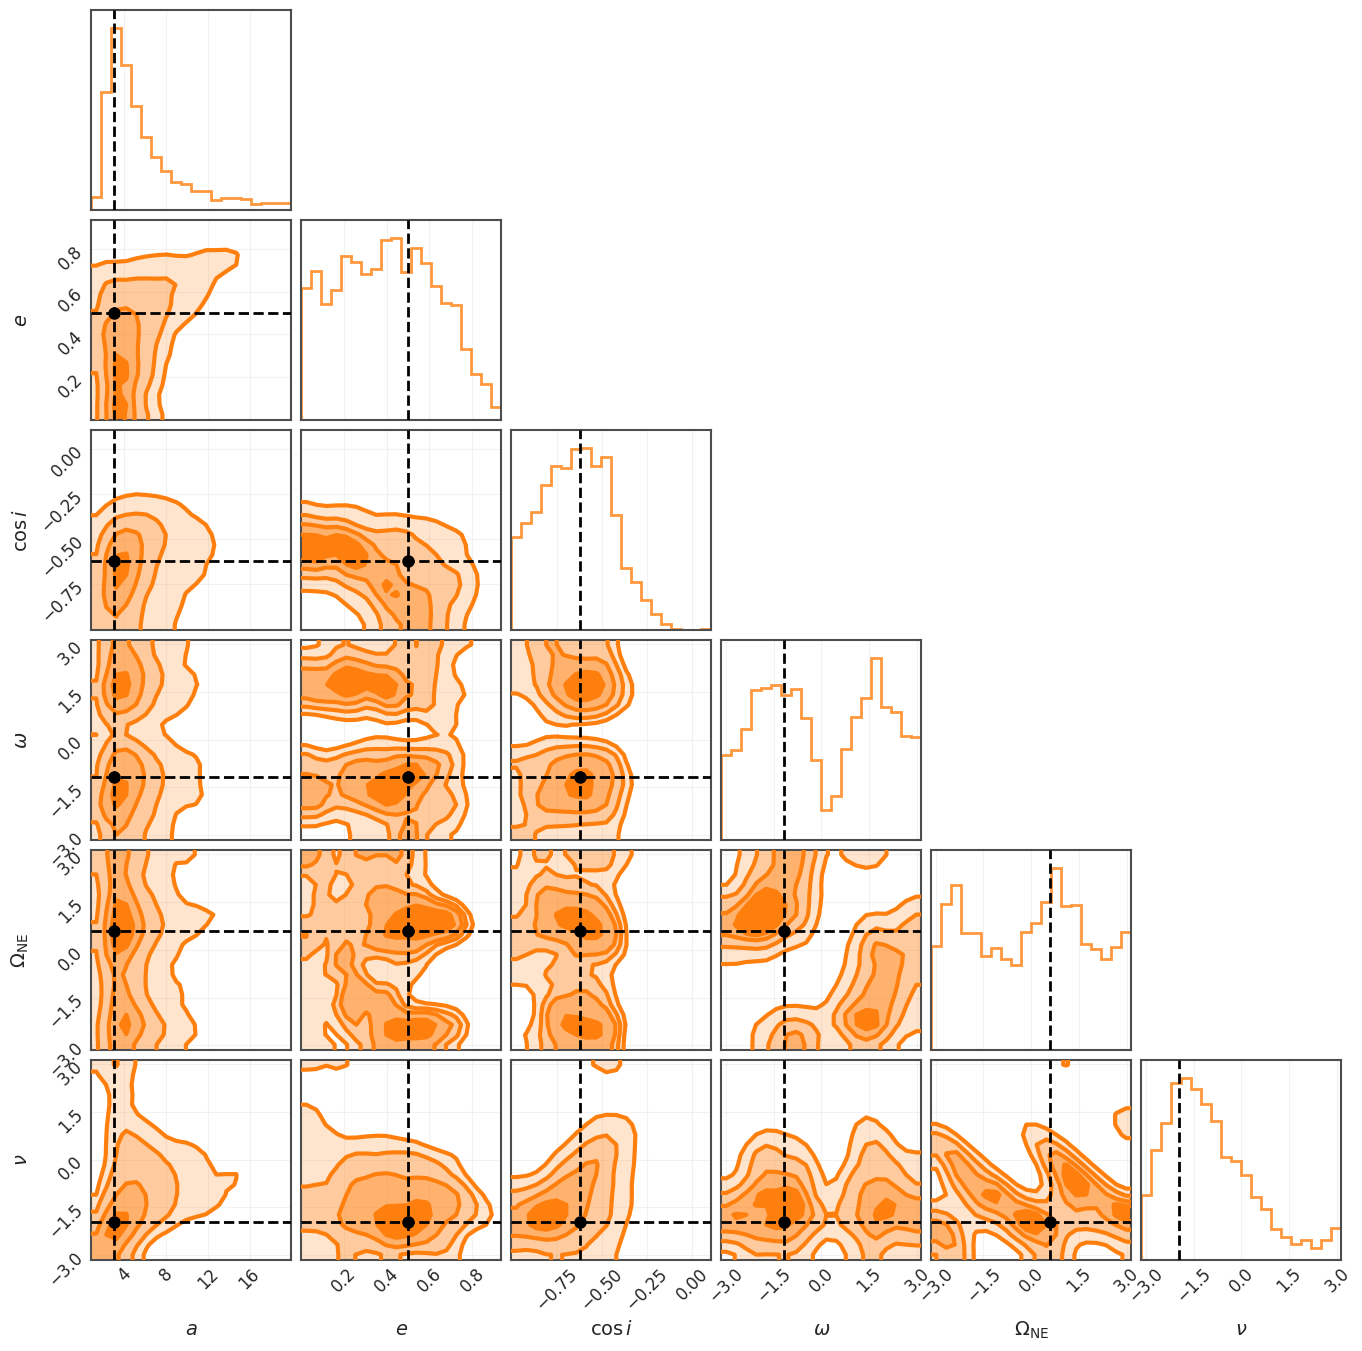

In [28]:
labels_all = [ r"$M_{\rm L}$", r"$D_{\rm L}$", r"$D_{\rm S}$", 
    r"$\mu_{\rm rel,N}$", r"$\mu_{\rm rel,E}$", 
    r"$a$", r"$e$", r"$\cos{i}$", r"$\omega$", r"$\Omega_{\rm NE}$", r"$\nu$"
]

ranges = [
    (-0.1, 1.5),
    (-0, 10),
    (-6, 6),
    (-6, 6),
]

gap_result_plot = gap_result[ind, 3:].copy()
truths = np.array(truths_kep)[5:].copy()

fig = corner.corner(
    gap_result_plot[:,5:],
    labels=labels_all[5:],
#     range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = gap_result_plot[:,5:].shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

# ylims = [
# (0, 3.7),
# (0, 0.5),
# (0, 0.55),
# (0, 0.6),
# ]
# for i in range(ndim):
#     axes[i, i].set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]


# fig.subplots_adjust(
#     left=0.08,
#     right=0.98,
#     bottom=0.08,
#     top=0.98,
#     wspace=0.05,
#     hspace=0.05,
# )

plt.show()
